Loaded cached Figure 2B inputs from: Figure2_B_cached_inputs.npz
all_vectors: (31847, 103)
all_spikes_label: (31847, 1)
UMAP(n_epochs=100, n_jobs=1, random_state=42, verbose=True)
Fri Sep 18 16:11:43 2026 Construct fuzzy simplicial set
Fri Sep 18 16:11:43 2026 Finding Nearest Neighbors
Fri Sep 18 16:11:43 2026 Building RP forest with 14 trees


/Users/dazhang/opt/anaconda3/envs/klab_cpu/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #271: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Fri Sep 18 16:11:45 2026 NN descent for 15 iterations
	 1  /  15
	 2  /  15
	 3  /  15
	 4  /  15
	Stopping threshold met -- exiting after 4 iterations
Fri Sep 18 16:11:51 2026 Finished Nearest Neighbor Search
Fri Sep 18 16:11:53 2026 Construct embedding


Epochs completed:   0%|            0/100 [00:00]

	completed  0  /  100 epochs
	completed  10  /  100 epochs
	completed  20  /  100 epochs
	completed  30  /  100 epochs
	completed  40  /  100 epochs
	completed  50  /  100 epochs
	completed  60  /  100 epochs
	completed  70  /  100 epochs
	completed  80  /  100 epochs
	completed  90  /  100 epochs
Fri Sep 18 16:12:01 2026 Finished embedding
[20013 25091 19758  3321 29040]
KMeans(n_clusters=5, random_state=920)


/Users/dazhang/opt/anaconda3/envs/klab_cpu/lib/python3.9/site-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


0.10299526


/var/folders/mc/21c8yz_54cs6zqn23gb1c0tm0000gn/T/ipykernel_85736/1073948934.py:144: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.figure.show()


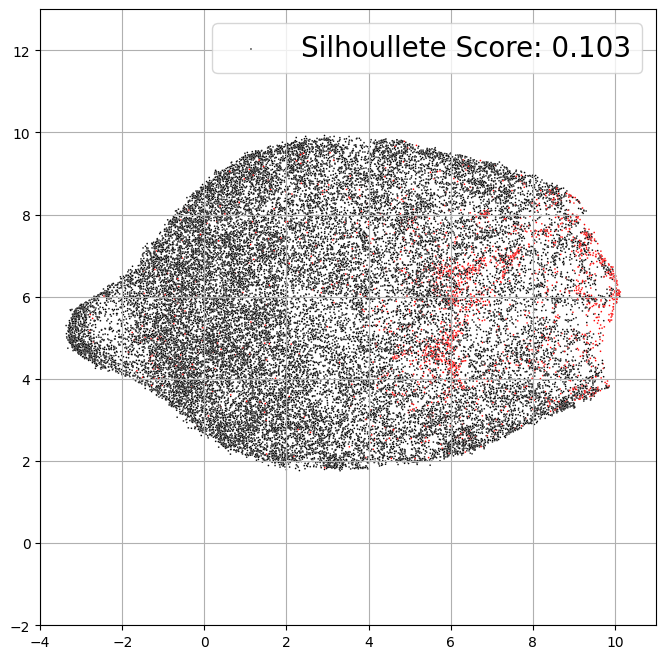

In [ ]:
# ============================================================
# Fast reproducible start for Figure 2B.
# This cell can be run directly after restarting the kernel.
# ============================================================
import collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap.umap_ as umap

from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min, silhouette_score
from sklearn.preprocessing import normalize

CACHE_FILE = "Figure2_B_cached_inputs.npz"
with np.load(CACHE_FILE, allow_pickle=False) as cached:
    all_vectors = cached["all_vectors"]
    all_spikes_label = cached["all_spikes_label"]

print(f"Loaded cached Figure 2B inputs from: {CACHE_FILE}")
print("all_vectors:", all_vectors.shape)
print("all_spikes_label:", all_spikes_label.shape)

def kl_divergence(p, q, eps=1e-10):
    p = np.clip(p, eps, 1)
    q = np.clip(q, eps, 1)
    return np.sum(p * np.log(p / q))



D_id_color = collections.defaultdict(str)

D_id_color['EC130_513'] = 'red'
D_id_color['EC131_513'] = 'green'
D_id_color['EC133_513'] = 'blue'
D_id_color['EC135_513'] = 'yellow'
D_id_color['EC137_513'] = 'pink'
D_id_color['EC143_513'] = 'purple'
D_id_color['EC157_513'] = 'brown'
D_id_color['EC162_513'] = 'cyan'
D_id_color['EC175_513'] = 'orange'
D_id_color['EC183_513'] = 'black'
D_id_color['EC186_513'] = 'gold'
D_id_color['EC187_513'] = 'rosybrown'
D_id_color['EC191_513'] = 'grey'
D_id_color['EC196_513'] = 'skyblue'
D_id_color['EC219_513'] = 'bisque'
D_id_color['EC220_513'] = 'tan'
D_id_color['EC221_513'] = 'khaki'
D_id_color['EC222_513'] = 'olive'


D_id_color[0] = 'blue'
D_id_color[1] = 'red'
D_id_color[2] = 'green'
D_id_color[3] = 'pink'
D_id_color[4] = 'cyan'
D_id_color[5] = 'purple'
D_id_color[6] = 'grey'
D_id_color[7] = 'khaki'
D_id_color[8] = 'orange'
D_id_color[9] = 'black'
D_id_color[10] = 'olive'
D_id_color[11] = 'brown'
D_id_color[12] = 'rosybrown'
D_id_color[13] = 'bisque'
D_id_color[14] = 'tan'
D_id_color[15] = 'yellow'
D_id_color[16] = 'gold'
D_id_color[17] = 'skyblue'
D_id_color[18] = 'magenta'
D_id_color[19] = 'darkblue'

embedding = umap.UMAP(n_components=2, min_dist=0.1, metric='euclidean', n_neighbors=15,random_state=42, n_epochs=100, verbose=True).fit_transform(all_vectors)

#Import required module
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
#Initialize the class object
#930 is good

number_cluster = 5
kmeans = KMeans(n_clusters = number_cluster,random_state = 920, n_init=10)

kmeans_label = kmeans.fit(embedding)
closest, all_points_w_labels = pairwise_distances_argmin_min(kmeans_label.cluster_centers_, embedding)

print(closest)
print(kmeans_label)


actual_score = silhouette_score(embedding, all_spikes_label)


def total_kl_divergence(X, labels):
    X = normalize(X, norm='l1', axis=1)  # Ensure all rows are valid distributions
    unique_labels = np.unique(labels)
    total_kl = 0
    labels = np.ravel(labels)

    for label in unique_labels:
        cluster_points = X[labels == label]
        if cluster_points.shape[0] == 0:
            continue
        centroid = np.mean(cluster_points, axis=0)
        centroid /= np.sum(centroid)  # Normalize to make it a distribution

        for x in cluster_points:
            total_kl += kl_divergence(x, centroid)

    return total_kl

total_kl = total_kl_divergence(embedding, all_spikes_label)


c_list = []
for i, txt in enumerate(all_spikes_label):
    spike = all_spikes_label[i]
    if spike == 0:
        # cc = [1, 1, 1]  # White
        cc = [0, 0, 0]   # Black
    else:
        cc = [1, 0, 0] 
        # cc = [0, 0, 0]
        # cc = [1, 1, 1]
    c_list.append(cc)


fig, ax = plt.subplots(figsize=(8,8))
ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=c_list, s=1.5)
# ax = sns.scatterplot(x=embedding[:,0], y=embedding[:,1], c=[D_id_color[f] for f in kmeans_label.labels_], s=0.8)

ax.grid(True)
ax.set_aspect('equal')

ax.set_xlim(-4, 11)
ax.set_ylim(-2, 13)
# ax.set_xticklabels([])
# ax.set_yticklabels([])
# ax.title.set_text("Patient with Psudo Kmeans Labels: ")
print(str(actual_score))
ax.legend(["Silhoullete Score: "+str(f"{actual_score:.3f}")], fontsize=20,ncol=1)
# ax.legend(["KL Divergence: "+str(f"{total_kl:.3f}")], fontsize=20, ncol=1)
ax.figure.show()
# ax.figure.savefig("kmeans_label_traces_"+str(number_cluster)+".png")
# plt.close()
